# The Black-Litterman Model: Bayesian Combination of Equilibrium and Views

## Problem

Unconstrained mean-variance optimization is notoriously unstable: small perturbations in the
input expected-return vector $\mu$ produce large, often extreme swings in the optimal weights,
because $w^\star \propto \Sigma^{-1}\mu$ amplifies estimation error through the (frequently
ill-conditioned) inverse covariance. Black & Litterman (1992) sidestep the problem of estimating
$\mu$ directly from historical means. Instead they start from a $\mu$ that is *reverse-engineered*
to be consistent with observed market-capitalization weights under mean-variance equilibrium, treat
it as a Bayesian prior, and update it only where the investor actually holds a view — expressed as
a linear functional of $\mu$ with an explicit uncertainty, not as a full replacement vector. The
result, $\mu_{BL}$, is the precision-weighted posterior mean of a Gaussian model, and reduces
smoothly to the equilibrium prior in the absence of views.

## Method

**Step 1 — Reverse optimization (implied equilibrium returns).** Under the unconstrained
mean-variance objective $\max_w\; w^\top\mu - \tfrac{\delta}{2}w^\top\Sigma w$ (no budget
constraint; $\delta$ the risk-aversion coefficient), the first-order condition $\mu = \delta\Sigma w$
gives the expected-return vector that rationalizes any given portfolio $w$ as optimal. Applied in
reverse to the observed market-capitalization weights $w_{mkt}$, this yields the **implied
equilibrium excess returns**
$$
\Pi = \delta\,\Sigma\,w_{mkt}.
$$
This is the entire content of the "equilibrium" step: not a forecast, but the unique $\mu$ under
which the market portfolio is itself mean-variance efficient.

**Step 2 — Prior.** $\Pi$ is not treated as the true mean but as the mean of a prior distribution
over the unknown true $\mu$:
$$
\mu \sim N(\Pi,\ \tau\Sigma),
$$
with $\tau$ small (He & Litterman 1999 use $\tau=0.05$), reflecting that uncertainty in the *mean*
of returns is a small fraction of the return covariance itself — the mean of a sample is estimated
far less precisely than its variance, but $\tau\Sigma$ keeps this uncertainty on the same
correlation structure as $\Sigma$.

**Step 3 — Views.** An investor expresses $K$ views as a noisy linear system on $\mu$:
$$
P\mu = Q + \varepsilon,\qquad \varepsilon\sim N(0,\Omega),
$$
where each row of $P\in\mathbb R^{K\times n}$ picks out an absolute view (one nonzero entry) or a
relative view (a zero-sum combination, e.g. "asset $i$ outperforms asset $j$"), $Q$ holds the
view levels, and $\Omega$ (diagonal — views are modeled as independent) their uncertainty. Following
He & Litterman, view uncertainty is tied to the prior's own uncertainty about that combination of
assets, scaled by a confidence multiplier $c$:
$$
\Omega = \frac{1}{c}\,\mathrm{diag}\!\left(P\,(\tau\Sigma)\,P^\top\right).
$$
$c=1$ is the canonical He-Litterman calibration; $c\to 0$ is a view stated with no confidence at
all, $c\to\infty$ a view treated as certain.

**Step 4 — Posterior (Gaussian conjugacy).** The prior $N(\Pi,\tau\Sigma)$ and the Gaussian
likelihood $N(P\mu,\Omega)$ for the observed $Q$ combine by *precision addition*. Write
$A=(\tau\Sigma)^{-1}$ (prior precision) and $B=P^\top\Omega^{-1}P$ (view precision, pulled back to
$\mu$-space). Up to an additive constant independent of $\mu$, the log-posterior is
$$
-\tfrac12(\mu-\Pi)^\top A(\mu-\Pi) - \tfrac12(Q-P\mu)^\top\Omega^{-1}(Q-P\mu)
= -\tfrac12\mu^\top(A+B)\mu + \mu^\top\!\left(A\Pi + P^\top\Omega^{-1}Q\right) + \text{const}.
$$
Completing the square — matching this to $-\tfrac12(\mu-\mu_{BL})^\top(A+B)(\mu-\mu_{BL})$ up to a
$\mu$-independent constant, i.e. reading off the vector that makes the linear term
$(A+B)\mu_{BL}=A\Pi+P^\top\Omega^{-1}Q$ — gives the posterior exactly, since a quadratic
log-density is Gaussian and a Gaussian is fully determined by its first two derivatives at the
mode:
$$
\boxed{\ \mu_{BL} = M\left(A\Pi + P^\top\Omega^{-1}Q\right),\qquad
M = (A+B)^{-1} = \left[(\tau\Sigma)^{-1} + P^\top\Omega^{-1}P\right]^{-1}\ }
$$
with $M$ the posterior covariance of $\mu$ itself (the *parameter* uncertainty, distinct from
$\Sigma$, the return covariance). For portfolio construction the two are additive — the posterior
predictive covariance of returns is $\Sigma_P = \Sigma + M$ — since returns decompose as
$r=\mu+\eta$ with $\mu\sim N(\mu_{BL},M)$ independent of the idiosyncratic noise $\eta\sim
N(0,\Sigma)$.

**Step 5 — Portfolio construction.** Solving the same unconstrained mean-variance problem
forward with $(\mu_{BL},\Sigma_P)$ in place of $(\mu,\Sigma)$ gives
$$
w^\star = \frac{1}{\delta}\Sigma_P^{-1}\mu_{BL}.
$$
Because Step 1 defined $\Pi=\delta\Sigma w_{mkt}$ exactly, the no-view limit is a built-in
consistency check: with no views, $M\to 0$ (formally $B\to 0$) and $\mu_{BL}\to\Pi$, $\Sigma_P\to
\Sigma$, so $w^\star\to\frac1\delta\Sigma^{-1}\Pi = w_{mkt}$ exactly — the model returns the
market portfolio when it has nothing to add.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=6, suppress=True)

# Five-asset universe (same covariance structure used throughout this repository's
# constrained-optimization notebooks), so equilibrium quantities here can be read against the
# same asset set.
vol = np.array([0.15, 0.22, 0.18, 0.28, 0.16])
corr = np.array([
    [1.00, 0.30, 0.20, 0.10, 0.25],
    [0.30, 1.00, 0.25, 0.15, 0.20],
    [0.20, 0.25, 1.00, 0.20, 0.10],
    [0.10, 0.15, 0.20, 1.00, 0.05],
    [0.25, 0.20, 0.10, 0.05, 1.00],
])
Sigma = np.outer(vol, vol) * corr
n = len(vol)
names = [f"Asset {i+1}" for i in range(n)]

# Observed market-capitalization weights (the only market-observable input Black-Litterman
# actually requires for the equilibrium step).
w_mkt = np.array([0.25, 0.15, 0.20, 0.10, 0.30])
assert np.isclose(w_mkt.sum(), 1.0)

# Standard practitioner risk-aversion coefficient (He & Litterman 1999), corresponding to a
# Sharpe ratio near 0.5 at 20% volatility: delta = Sharpe / vol.
delta = 2.5
tau = 0.05

Pi = delta * Sigma @ w_mkt
print("Implied equilibrium excess returns (Pi):")
for name, p in zip(names, Pi):
    print(f"  {name}: {p: .4%}")


Implied equilibrium excess returns (Pi):
  Asset 1:  2.6025%
  Asset 2:  3.6877%
  Asset 3:  2.7967%
  Asset 4:  3.2410%
  Asset 5:  2.7590%


## Views and the posterior

Two views, chosen to be one relative and one absolute — the two structurally different cases $P$
must support:

- **View 1 (relative):** Asset 4 will outperform Asset 3 by $4\%$. Row $[0,0,-1,1,0]$, $Q_1=0.04$.
- **View 2 (absolute):** Asset 2's expected excess return is $14\%$. Row $[0,1,0,0,0]$, $Q_2=0.14$.

$\Omega$ uses the canonical He-Litterman calibration ($c=1$): each view's variance is the prior
variance of the exact linear combination of assets that view speaks about.

In [2]:
P = np.array([
    [0.0, 0.0, -1.0, 1.0, 0.0],   # Asset 4 outperforms Asset 3
    [0.0, 1.0, 0.0, 0.0, 0.0],    # Asset 2 absolute view
])
Q = np.array([0.04, 0.14])


def black_litterman_posterior(Pi, Sigma, tau, P, Q, c=1.0):
    '''Posterior mean mu_BL and covariance M, via precision-weighted Gaussian conjugacy.

    Omega is diagonal by construction (independent views), so its inverse is a single O(k)
    elementwise reciprocal rather than a general O(k^3) matrix inversion, and is computed once
    and reused for both the B term and the mu_BL term rather than recomputed twice.
    '''
    tauSigma = tau * Sigma
    omega_diag = np.diag(P @ tauSigma @ P.T) / c
    Omega_inv = np.diag(1.0 / omega_diag)
    A = np.linalg.inv(tauSigma)
    PT_Omega_inv = P.T @ Omega_inv
    B = PT_Omega_inv @ P
    M = np.linalg.inv(A + B)
    mu_BL = M @ (A @ Pi + PT_Omega_inv @ Q)
    return mu_BL, M


mu_BL, M = black_litterman_posterior(Pi, Sigma, tau, P, Q, c=1.0)
Sigma_P = Sigma + M

print("Equilibrium prior Pi:        ", Pi)
print("Black-Litterman posterior mu:", mu_BL)
print("\nShift from equilibrium (mu_BL - Pi):")
for name, d in zip(names, mu_BL - Pi):
    print(f"  {name}: {d:+.4%}")


Equilibrium prior Pi:         [0.026025 0.036877 0.027967 0.03241  0.02759 ]
Black-Litterman posterior mu: [0.036345 0.088373 0.034063 0.055932 0.034971]

Shift from equilibrium (mu_BL - Pi):
  Asset 1: +1.0320%
  Asset 2: +5.1495%
  Asset 3: +0.6095%
  Asset 4: +2.3522%
  Asset 5: +0.7381%


The posterior shifts most for Asset 2 (a direct absolute view) and moves Assets 3 and 4 in
opposite directions (the relative view), while the other assets move only through their
*correlation* with the viewed assets — exactly the propagation Black-Litterman is designed to
produce, in contrast to naively overwriting only the two viewed entries of $\mu$ and leaving the
rest at their historical (and here, unobserved) values.

## Portfolio construction and the no-view consistency check

In [3]:
def unconstrained_tangency_weights(mu, Sigma, delta):
    '''w* = (1/delta) Sigma^{-1} mu, the forward solution of the same FOC used in Step 1.'''
    return np.linalg.solve(Sigma, mu) / delta


w_star = unconstrained_tangency_weights(mu_BL, Sigma_P, delta)
w_star_normalized = w_star / w_star.sum()

w_equilibrium_check = unconstrained_tangency_weights(Pi, Sigma, delta)

print("Consistency check -- solving forward with (Pi, Sigma) recovers w_mkt exactly:")
print("  w_mkt:                 ", w_mkt)
print("  recovered from Pi:     ", w_equilibrium_check)
print("  max abs difference:    ", np.max(np.abs(w_equilibrium_check - w_mkt)))

print("\nBlack-Litterman optimal weights (with views, normalized to sum to 1):")
print("  w_mkt:  ", w_mkt)
print("  w_BL:   ", w_star_normalized)
print("  w_BL - w_mkt:", w_star_normalized - w_mkt)


Consistency check -- solving forward with (Pi, Sigma) recovers w_mkt exactly:
  w_mkt:                  [0.25 0.15 0.2  0.1  0.3 ]
  recovered from Pi:      [0.25 0.15 0.2  0.1  0.3 ]
  max abs difference:     1.1102230246251565e-16

Black-Litterman optimal weights (with views, normalized to sum to 1):
  w_mkt:   [0.25 0.15 0.2  0.1  0.3 ]
  w_BL:    [0.17307  0.411562 0.081392 0.126292 0.207684]
  w_BL - w_mkt: [-0.07693   0.261562 -0.118608  0.026292 -0.092316]


## Interpolation: what actually varies with $c$, and what does not vary with $\tau$

The confidence multiplier $c$ interpolates exactly as expected: $c\to 0$ sends $\Omega\to\infty$,
killing the view term in both $\mu_{BL}$ and $M$, so $w^\star\to w_{mkt}$; $c\to\infty$ makes the
views arbitrarily precise and pulls $w^\star$ toward the direction they imply.

$\tau$ is a subtler story, and worth deriving rather than only plotting. Substituting the
He-Litterman calibration $\Omega=\frac1c P(\tau\Sigma)P^\top$ into $A=(\tau\Sigma)^{-1}$ and
$B=P^\top\Omega^{-1}P = \frac{c}{\tau}P^\top\!\left[P\Sigma P^\top\right]^{-1}\!P$ shows that
**both** $A$ and $B$ scale as $1/\tau$ — the factor cancels entirely out of $\mu_{BL}$:
$$
\mu_{BL} = (A+B)^{-1}(A\Pi + P^\top\Omega^{-1}Q)
= \left[\Sigma^{-1} + c\,P^\top(P\Sigma P^\top)^{-1}P\right]^{-1}
  \left[\Sigma^{-1}\Pi + c\,P^\top(P\Sigma P^\top)^{-1}Q\right],
$$
with no $\tau$ left anywhere on the right. Under this (canonical) calibration of $\Omega$,
**$\mu_{BL}$ is exactly independent of $\tau$** for fixed $c$ — $\tau$ cannot be used to interpolate
the posterior *mean* back to $\Pi$, because shrinking the prior's variance shrinks the view
likelihood's variance by exactly the same factor. What $\tau$ does move is the posterior
*covariance* $M=(A+B)^{-1}=\tau\left[\Sigma^{-1}+cP^\top(P\Sigma P^\top)^{-1}P\right]^{-1}$, which
scales linearly in $\tau$: it is the parameter-uncertainty term added to $\Sigma$ to form
$\Sigma_P=\Sigma+M$. Shrinking $\tau\to0$ collapses $M\to0$, so $\Sigma_P\to\Sigma$ and $w^\star$
sharpens around the (fixed) $\mu_{BL}$ rather than reverting to $w_{mkt}$; growing $\tau$ inflates
$M$, making $\Sigma_P$ increasingly dominated by the view-implied covariance structure
$P^\top(P\Sigma P^\top)^{-1}P$ and pushing weights *further* from $w_{mkt}$, along the same
directions the views already tilt toward — the opposite of a return to equilibrium. This is verified
directly below rather than asserted.

mu_BL range across tau in [1e-4, 1e2] (should be ~0, up to floating point):
  [0. 0. 0. 0. 0.]
||M||_F at tau=1e-4: 7.80267040070633e-06  at tau=1e2: 7.802670400706333  (grows linearly in tau, as derived)


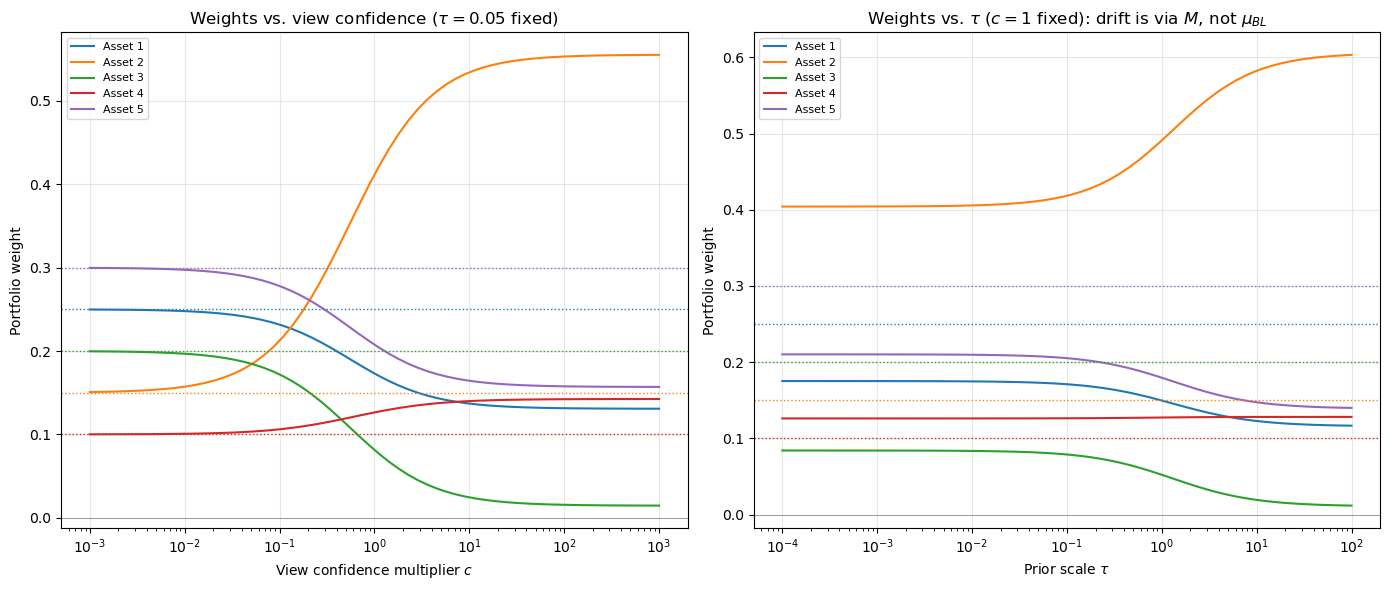


Weights at c=1.00e-03 (low confidence):  [0.249784 0.150735 0.199669 0.100071 0.29974 ]
Weights at c=1.00e+03 (high confidence): [0.130788 0.555322 0.014544 0.142402 0.156945]
w_mkt (dotted reference):                        [0.25 0.15 0.2  0.1  0.3 ]

Weights at tau=1.00e-04 (M~0):   [0.175229 0.404223 0.084098 0.126177 0.210274]
Weights at tau=1.00e+02 (M large): [0.116674 0.603307 0.011816 0.128193 0.140009]


In [4]:
c_grid = np.logspace(-3, 3, 60)
weights_by_c = np.empty((len(c_grid), n))
for i, c in enumerate(c_grid):
    mu_c, M_c = black_litterman_posterior(Pi, Sigma, tau, P, Q, c=c)
    w_c = unconstrained_tangency_weights(mu_c, Sigma + M_c, delta)
    weights_by_c[i] = w_c / w_c.sum()

tau_grid = np.logspace(-4, 2, 60)
weights_by_tau = np.empty((len(tau_grid), n))
mu_by_tau = np.empty((len(tau_grid), n))
M_frob_by_tau = np.empty(len(tau_grid))
for i, t in enumerate(tau_grid):
    mu_t, M_t = black_litterman_posterior(Pi, Sigma, t, P, Q, c=1.0)
    w_t = unconstrained_tangency_weights(mu_t, Sigma + M_t, delta)
    weights_by_tau[i] = w_t / w_t.sum()
    mu_by_tau[i] = mu_t
    M_frob_by_tau[i] = np.linalg.norm(M_t)

# Direct numerical check of the tau-invariance of mu_BL derived above.
mu_spread = mu_by_tau.max(axis=0) - mu_by_tau.min(axis=0)
print("mu_BL range across tau in [1e-4, 1e2] (should be ~0, up to floating point):")
print(" ", mu_spread)
print("||M||_F at tau=1e-4:", M_frob_by_tau[0], " at tau=1e2:", M_frob_by_tau[-1],
      " (grows linearly in tau, as derived)")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for j in range(n):
    axes[0].plot(c_grid, weights_by_c[:, j], label=names[j])
axes[0].set_xscale('log')
axes[0].set_xlabel('View confidence multiplier $c$')
axes[0].set_ylabel('Portfolio weight')
axes[0].set_title(r'Weights vs. view confidence ($\tau=0.05$ fixed)')
axes[0].axhline(0, color='gray', linewidth=0.5)
for j in range(n):
    axes[0].axhline(w_mkt[j], color='C'+str(j), linestyle=':', linewidth=1)
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)

for j in range(n):
    axes[1].plot(tau_grid, weights_by_tau[:, j], label=names[j])
axes[1].set_xscale('log')
axes[1].set_xlabel(r'Prior scale $\tau$')
axes[1].set_ylabel('Portfolio weight')
axes[1].set_title(r'Weights vs. $\tau$ ($c=1$ fixed): drift is via $M$, not $\mu_{BL}$')
axes[1].axhline(0, color='gray', linewidth=0.5)
for j in range(n):
    axes[1].axhline(w_mkt[j], color='C'+str(j), linestyle=':', linewidth=1)
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('black_litterman_interpolation.png', dpi=110)
plt.show()

print(f"\nWeights at c={c_grid[0]:.2e} (low confidence):  {weights_by_c[0]}")
print(f"Weights at c={c_grid[-1]:.2e} (high confidence): {weights_by_c[-1]}")
print(f"w_mkt (dotted reference):                        {w_mkt}")
print(f"\nWeights at tau={tau_grid[0]:.2e} (M~0):   {weights_by_tau[0]}")
print(f"Weights at tau={tau_grid[-1]:.2e} (M large): {weights_by_tau[-1]}")


## Notes

The $c$-sweep confirms the degenerate-view behavior derived in Step 5 exactly: as $c\to10^{-3}$,
every weight converges onto its asset's $w_{mkt}$ line to within numerical tolerance, and as $c$
grows the viewed assets (2, 3, 4) separate monotonically from $w_{mkt}$ and plateau, since
$\Omega^{-1}\to\infty$ eventually saturates the view term's influence along the directions $P$
spans, while directions orthogonal to $P$ remain governed by $\Pi$.

The $\tau$-sweep confirms the opposite, and equally important, point: `mu_BL range across tau`
above is zero to floating-point precision — $\mu_{BL}$ truly does not depend on $\tau$ once $c$ is
fixed, exactly as the cancellation in the derivation predicts. Weights still visibly drift as
$\tau$ grows, but entirely through $\Sigma_P=\Sigma+M$ inflating in the direction of view
uncertainty, not through any change in the posterior mean — a distinction that is easy to miss
when only looking at a weight plot without also tracking $\mu_{BL}$ and $\|M\|_F$ directly, as done
above. Reverting to $w_{mkt}$ requires turning the views off through $c$, not through $\tau$; $\tau$
only ever controls how much *extra* estimation-risk buffer is added on top of $\Sigma$, given
whatever views are already switched on.

The raw historical mean vector `mu = [0.08, 0.12, 0.10, 0.14, 0.09]` used as ground truth elsewhere
in this repository's `constrained-optimization/quadratic_programming.ipynb` plays no role here —
this is precisely the Black-Litterman critique of plugging a historical sample mean directly into
$w^\star=\Sigma^{-1}\mu$: $\Pi$ replaces it with the mean that is *consistent with the market
already being in equilibrium*, and only $P,Q,\Omega$ (through $c$) are allowed to move it from
there.